# Python Fixed-Point Simulator

# Task 1: Inspect golden vectors from SW

Confirm that the .npz files match the spec: seven fields, correct shapes and dtypes.
Goal: decide whether files are usable as-is or need to go back to SW.

In [1]:
import numpy as np
from pathlib import Path

VECTOR_DIR = Path("../goldenVectors")

files = sorted(VECTOR_DIR.glob("test_*.npz"))
print(f"Found {len(files)} vector files:")
for f in files:
    print(f" {f.name}")

Found 5 vector files:
 test_01_easy_margin.npz
 test_02_tight_margin.npz
 test_03_winner_near_index_0.npz
 test_04_winner_near_index_N.npz
 test_05_engineered_tie.npz


In [11]:
EXPECTED_FIELDS = {
    'D_float':      (np.float32, (128, 256)),
    'r_float':      (np.float32, (128,)),
    'D_q15':        (np.int16, (128, 256)),
    'r_q15':        (np.int16, (128,)),
    'expected_idx': (np.int32, ()),
    'expected_val': (np.int64, ())
}

In [14]:
def inspect(path):
    """Print a structural report on one .npz file. Returns a dict of results
    so we can aggregate across files later."""
    npz = np.load(path)
    print(f"=== {path.name} ===")
    print(f"Fields present: {sorted(npz.files)}\n")

    report = {'path': path.name, 'missing': [], 'mismatched': [], 'ok': []}

    for name, (want_dtype, want_shape) in EXPECTED_FIELDS.items():
        if name not in npz.files:
            print(f"  MISSING:  {name}")
            report['missing'].append(name)
            continue
        arr = npz[name]
        dtype_ok = arr.dtype == want_dtype
        shape_ok = arr.shape == want_shape
        if dtype_ok and shape_ok:
            print(f"  OK:       {name}: dtype={arr.dtype}, shape={arr.shape}")
            report['ok'].append(name)
        else:
            print(f"  MISMATCH: {name}: dtype={arr.dtype} (want {want_dtype.__name__}), "
                  f"shape={arr.shape} (want {want_shape})")
            report['mismatched'].append(name)

    # Scalar values, if present
    print()
    if 'expected_idx' in npz.files:
        print(f"  expected_idx = {int(npz['expected_idx'])}")
    if 'expected_val' in npz.files:
        print(f"  expected_val = {int(npz['expected_val'])}")

    # Range sanity on quantized arrays
    if 'D_q15' in npz.files:
        d = npz['D_q15']
        print(f"  D_q15 range: [{d.min()}, {d.max()}]")
    if 'r_q15' in npz.files:
        r = npz['r_q15']
        print(f"  r_q15 range: [{r.min()}, {r.max()}]")

    print()
    return report

In [15]:
reports = [inspect(f) for f in files]

=== test_01_easy_margin.npz ===
Fields present: ['D_float', 'D_q15', 'expected_idx', 'expected_val', 'r_float', 'r_q15']

  OK:       D_float: dtype=float32, shape=(128, 256)
  OK:       r_float: dtype=float32, shape=(128,)
  OK:       D_q15: dtype=int16, shape=(128, 256)
  OK:       r_q15: dtype=int16, shape=(128,)
  OK:       expected_idx: dtype=int32, shape=()
  OK:       expected_val: dtype=int64, shape=()

  expected_idx = 105
  expected_val = 849555399
  D_q15 range: [-11772, 11328]
  r_q15 range: [-6660, 4723]

=== test_02_tight_margin.npz ===
Fields present: ['D_float', 'D_q15', 'expected_idx', 'expected_val', 'r_float', 'r_q15']

  OK:       D_float: dtype=float32, shape=(128, 256)
  OK:       r_float: dtype=float32, shape=(128,)
  OK:       D_q15: dtype=int16, shape=(128, 256)
  OK:       r_q15: dtype=int16, shape=(128,)
  OK:       expected_idx: dtype=int32, shape=()
  OK:       expected_val: dtype=int64, shape=()

  expected_idx = 232
  expected_val = 525132622
  D_q15 rang

In [16]:
print("Summary across all files:")
print(f"  Total files: {len(reports)}")
all_clean = all(not r['missing'] and not r['mismatched'] for r in reports)
print(f"  All clean:   {all_clean}")
if not all_clean:
    for r in reports:
        if r['missing'] or r['mismatched']:
            print(f"    {r['path']}: missing={r['missing']}, mismatched={r['mismatched']}")

Summary across all files:
  Total files: 5
  All clean:   True


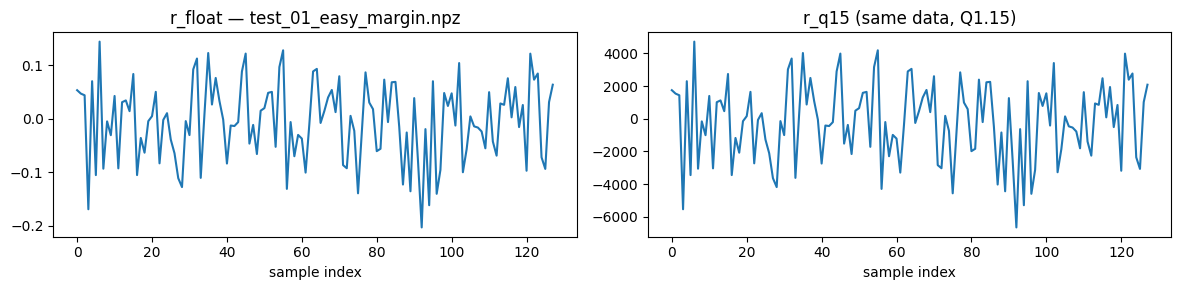

In [6]:
import matplotlib.pyplot as plt

npz = np.load(files[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(npz['r_float'])
axes[0].set_title(f"r_float — {files[0].name}")
axes[0].set_xlabel('sample index')
axes[1].plot(npz['r_q15'])
axes[1].set_title('r_q15 (same data, Q1.15)')
axes[1].set_xlabel('sample index')
plt.tight_layout()
plt.show()

# Task 1: Update
Task 1 done. All 5 golden vectors match §9 spec (six fields, correct dtypes and shapes). Files are usable as-is